# <h1><center>Introduction to Machine Learning and Data Science</center></h1>
# <h1><center>Assignment 3</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of the proof.</center></h1>
### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
### <h1><center>TA: Cevahir Koprulu</center></h1>
#### <h1><center>Due: 11pm 10/12/2026</center></h1>
### Submit a single pdf. All code outputs should be reported in the pdf.

Download the latest version of the lecture notes before starting. Question and exercise numbering refers to that version.

A subset of these questions will be graded. The subset is not announced in advance, so answer all twelve.

In this class, unless otherwise stated, all vectors are column vectors, and they are written in boldface fonts.

In [13]:
# --- COE 379L standard preamble ---------------------------------
# Pin versions so this notebook still runs next semester.
!pip install -q "jax[cpu]==0.4.35" "optax==0.2.3" "ucimlrepo"

import jax, jax.numpy as jnp, numpy as np, platform
import matplotlib.pyplot as plt

# Double precision. Read Section C.3 before removing this line.
jax.config.update("jax_enable_x64", True)

print("python  :", platform.python_version())
print("jax     :", jax.__version__)
print("devices :", jax.devices())
print("x64 on  :", jnp.zeros(1).dtype == jnp.float64)

/usr/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


python  : 3.13.5
jax     : 0.4.35
devices : [CpuDevice(id=0)]
x64 on  : True


---

## Question 1

*Notes, Chapter 6, Exercise 25.*

Reproduce Figure 6.2. Using (6.4), fit polynomials of every degree from 0 to 14 and record training and held out loss, averaging over 400 independent noise draws. Confirm that held out loss is minimized at degree 5 and rises by a factor of about 512 by degree 14, and that training loss at degree 14 is zero to machine precision. Explain that last fact exactly: why must it be zero, and what would change with 16 points? Finally, plot the noise floor $\sigma^2/2$ and confirm no held out curve goes below it.

Optimal Fitting Degree: 5
Amplification Factor of Heldout Loss: 513.6567
Training Loss at Overfit (14-degree) Polynomial: 1.4005879248784638e-23
Noise Floor: 0.0072


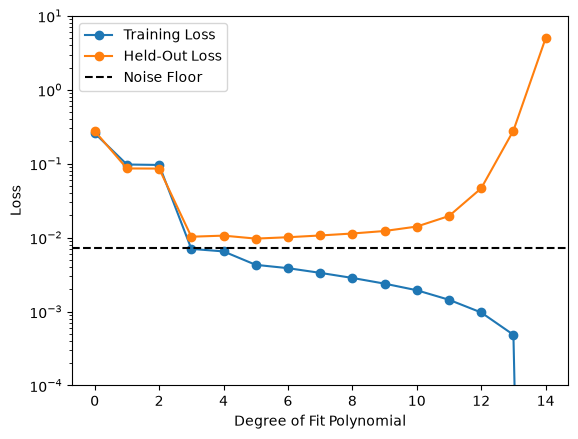

In [14]:
# Question 1: your code here

# Parameters
a, b = 0.3, 6.1
sigma = 0.12
n_train = 15
N_iters = 400
n_heldout = 200

# Target Function and Domain Discretization
tgt = jnp.sin
x_train = jnp.linspace(a, b, n_train)
x_held = jnp.linspace(a, b, n_heldout)
tgt_train = tgt(x_train)
tgt_heldout = tgt(x_held)

key = jax.random.PRNGKey(0)

@jax.jit
def single_draw(key, phi_pinv, phi_tr, phi_he):
    key_train, key_heldout = jax.random.split(key)
    y_train = tgt_train + sigma*jax.random.normal(key_train, tgt_train.shape)
    y_heldout = tgt_heldout + sigma*jax.random.normal(key_heldout, tgt_heldout.shape)
    
    theta = phi_pinv @ y_train
    loss_train = jnp.linalg.norm(phi_tr@theta - y_train)**2 / (2*n_train)
    loss_heldout = jnp.linalg.norm(phi_he@theta - y_heldout)**2 / (2*n_heldout)

    return (loss_train, loss_heldout)

keys = jax.random.split(key, N_iters)
make_vander = lambda x,d: jnp.vander(2*(x-a)/(b-a) - 1, d+1, increasing=True)
train_loss, heldout_loss = np.zeros(15), np.zeros(15)
for d in range(15):
    phi_train = make_vander(x_train, d)
    phi_heldout = make_vander(x_held, d)
    train, heldout = jax.vmap(single_draw, in_axes=(0,None,None,None))(keys,jnp.linalg.pinv(phi_train),phi_train,phi_heldout)

    train_loss[d], heldout_loss[d] = float(train.mean()), float(heldout.mean())

d_star = jnp.argmin(heldout_loss)
loss_amp = heldout_loss[14] / heldout_loss[d_star]
print(f"Optimal Fitting Degree: {d_star}")
print(f"Amplification Factor of Heldout Loss: {loss_amp:.4f}")
print(f"Training Loss at Overfit (14-degree) Polynomial: {train_loss[14]}")
print(f"Noise Floor: {0.5*sigma**2:.4f}")

plt.figure()
plt.plot(jnp.arange(15), train_loss, marker='o', label='Training Loss')
plt.plot(jnp.arange(15), heldout_loss, marker='o', label="Held-Out Loss")
plt.yscale('log')
plt.ylim(1e-4, 1e1)
plt.axhline(y=0.5*sigma**2, linestyle="--", label="Noise Floor", color="black")
plt.xlabel("Degree of Fit Polynomial")
plt.ylabel("Loss")
plt.legend()

plt.savefig("HW3Problem1.jpg")

---

## Question 2

*Notes, Chapter 6, Exercise 26.*

Reproduce Figure 6.3. The caption claims the $L_1$ solution is exactly $(1.00, 0.00)$ rather than something merely close. Choose a two dimensional quadratic loss and a radius $r$, then solve $\min J(\boldsymbol{\theta})$ subject to $\|\boldsymbol{\theta}\|_1 \le r$ numerically, and separately subject to $\|\boldsymbol{\theta}\|_2 \le r$. Report both minimizers to six decimals. Then perturb the loss slightly and rerun: which of the two minimizers moves continuously, and which stays pinned at a vertex until the perturbation is large enough? This is Definition 6.7.1 as a computational fact rather than a picture.

L1 minimizer: [1. 0.]
L2 minimizer: [0.950793 0.309827]
c1 shifted by -0.0: L1 = [1. 0.], L2 = [0.950793 0.309827]
c1 shifted by -0.2: L1 = [1. 0.], L2 = [0.947423 0.319985]
c1 shifted by -0.5: L1 = [1. 0.], L2 = [0.939458 0.342665]
L1 minimizer leaves (1, 0) when c1 < 1.166666 (analytic: 7/6 = 1.166667)


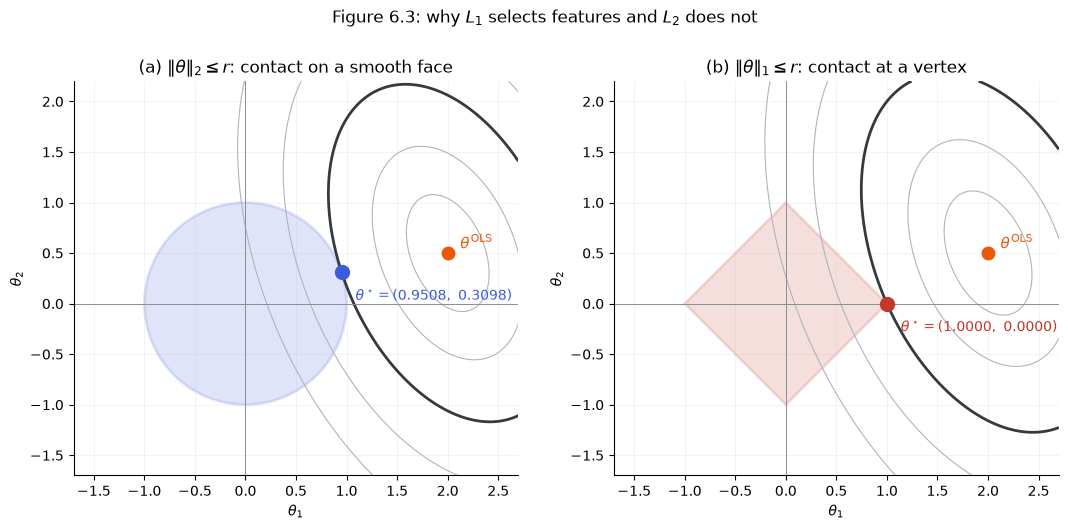

In [15]:
# Question 2: your code here
A = jnp.array([[2.0, 0.5],
               [0.5, 1.0]])
r = 1.0
c = jnp.array([2.0, 0.5])
eta = 1.0/jnp.linalg.eigvalsh(A).max()

def proj_l2(v):
    n = jnp.linalg.norm(v)
    return jnp.where(n <= r, v, r*v/n)

def proj_l1(v):
    u = jnp.sort(jnp.abs(v))[::-1]
    css = jnp.cumsum(u)
    k = jnp.sum(u*jnp.arange(1, v.size + 1) > (css - r)) - 1
    tau = (css[k] - r)/(k + 1.0)
    proj = jnp.sign(v)*jnp.maximum(jnp.abs(v) - tau, 0.0)
    return jnp.where(jnp.sum(jnp.abs(v)) <= r, v, proj)

def solve_constrained(c, proj, n_iter=20000):
    body = lambda _, th: proj(th - eta*(A @ (th - c)))
    return jax.lax.fori_loop(0, n_iter, body, jnp.zeros(2))

solve_constrained = jax.jit(solve_constrained, static_argnames="proj")

theta_l1 = solve_constrained(c, proj_l1)
theta_l2 = solve_constrained(c, proj_l2)
print("L1 minimizer:", np.round(np.asarray(theta_l1), 6))
print("L2 minimizer:", np.round(np.asarray(theta_l2), 6))

for d in [0.0, 0.2, 0.5]:
    cp = c + jnp.array([-d, 0.0])
    print(f"c1 shifted by -{d:.1f}: "
          f"L1 = {np.round(np.asarray(solve_constrained(cp, proj_l1)), 6)}, "
          f"L2 = {np.round(np.asarray(solve_constrained(cp, proj_l2)), 6)}")

lo, hi = 0.0, 1.0
for _ in range(60):
    mid = (lo + hi)/2
    th = solve_constrained(jnp.array([2.0 - mid, 0.5]), proj_l1)
    if jnp.linalg.norm(th - jnp.array([1.0, 0.0])) < 1e-6:
        lo = mid
    else:
        hi = mid
print(f"L1 minimizer leaves (1, 0) when c1 < {2.0 - lo:.6f} (analytic: 7/6 = {7/6:.6f})")

from matplotlib.patches import Circle, Polygon

G1, G2 = jnp.meshgrid(jnp.linspace(-1.7, 2.7, 400), jnp.linspace(-1.7, 2.2, 400))
U1, U2 = G1 - c[0], G2 - c[1]
Z = 0.5*(A[0,0]*U1**2 + 2*A[0,1]*U1*U2 + A[1,1]*U2**2)      # J(theta) on the grid

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
panels = [(axes[0], theta_l2, "L2", "#3b5bdb",
           r"(a) $\|\theta\|_2\leq r$: contact on a smooth face"),
          (axes[1], theta_l1, "L1", "#c0392b",
           r"(b) $\|\theta\|_1\leq r$: contact at a vertex")]

for ax, sol, kind, col, title in panels:
    Jstar = 0.5*(sol - c) @ A @ (sol - c)                   # level set through the solution
    ax.contour(G1, G2, Z, levels=jnp.array([.12,.4,1.0,1.9,3.1])*Jstar,
               colors="#adb5bd", linewidths=.8)
    ax.contour(G1, G2, Z, levels=[Jstar], colors="#343a40", linewidths=2.0)

    region = Circle((0,0), r) if kind == "L2" else Polygon([(r,0),(0,r),(-r,0),(0,-r)])
    region.set(facecolor=col, alpha=.16, edgecolor=col, linewidth=2)
    ax.add_patch(region)

    ax.plot(*c, "o", ms=9, color="#e8590c")
    ax.annotate(r"$\theta^{\rm OLS}$", c, xytext=(9, 3), textcoords="offset points",
                color="#e8590c", fontsize=11)
    ax.plot(*sol, "o", ms=10, color=col, zorder=5)
    ax.annotate(rf"$\theta^\star=({sol[0]:.4f},\ {sol[1]:.4f})$", sol,
                xytext=(10, -20), textcoords="offset points", color=col, fontsize=10)

    ax.axhline(0, lw=.7, color="#868e96"); ax.axvline(0, lw=.7, color="#868e96")
    ax.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", aspect="equal",
           xlim=(-1.7, 2.7), ylim=(-1.7, 2.2), title=title)
    ax.grid(alpha=.2, lw=.5); ax.spines[["top","right"]].set_visible(False)

fig.suptitle(r"Figure 6.3: why $L_1$ selects features and $L_2$ does not", y=1.00, fontsize=12)
fig.tight_layout()
plt.savefig("HW3Problem2.png", dpi=150, bbox_inches="tight")

---

## Question 3

*Notes, Chapter 6, Exercise 27.*

Reproduce Figure 6.4. With 8 features of which three carry signal $(2.0, -1.4, 0.9)$, $n = 60$ and $\sigma = 0.5$, trace ridge and lasso coefficients over four decades of $\lambda$. Count exact zeros in each path: not coefficients below a threshold, but values equal to zero in floating point. You should find none for ridge anywhere, and several hundred for lasso. Report the $\lambda$ at which the last noise feature dies and the $\lambda$ at which the first signal feature does, and say what the gap between them means for feature selection.

Exact Zeros in Ridge Path: 0
Exact Zeros in Lasso Path: 805
λ which the last noise feature dies: 0.03872038781812557
λ which the first signal feature dies: 0.9011018251665022


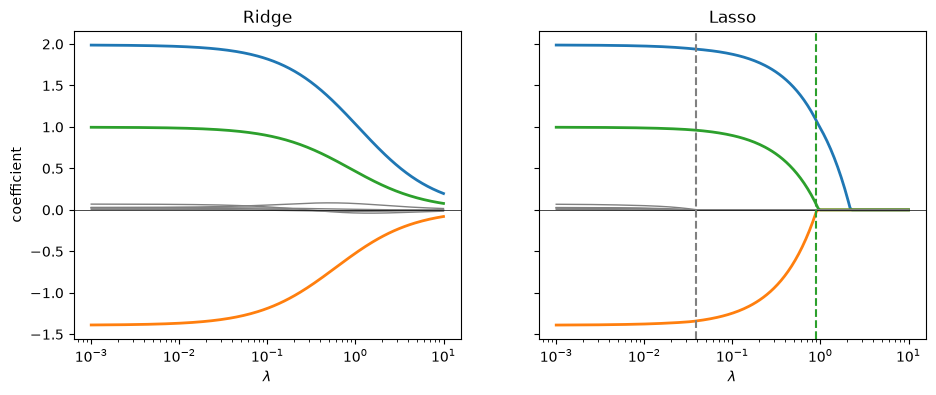

In [16]:
# Question 3: your code here

# Data Generation
n_features = 8
n_samples = 60
sigma = 0.5

theta_true = jnp.zeros(n_features).at[:3].set(jnp.array([2.0, -1.4, 0.9]))
key_data, key_noise = jax.random.split(jax.random.PRNGKey(0))

X_data = jax.random.normal(key_data, shape=(n_samples, n_features))
y_data = X_data @ theta_true + sigma*jax.random.normal(key_noise, shape=(n_samples,))

# Ridge Regularization
lambdas = jnp.logspace(-3,1,200)

@jax.jit
def solve_ridge(lambda_):
    theta = jnp.linalg.solve((X_data.T @ X_data)/n_samples + lambda_*jnp.eye(n_features),(X_data.T @ y_data)/n_samples)
    return theta

ridge_path = jax.vmap(solve_ridge)(lambdas)

# Lasso Regularization
soft = lambda v, t: jnp.sign(v) * jnp.maximum(jnp.abs(v) - t, 0.0)
eta = 1.0 / jnp.linalg.eigvalsh((X_data.T @ X_data)/n_samples).max()

@jax.jit
def lasso(lam):
    body = lambda i, th: soft(th - eta * ((X_data.T @ X_data)/n_samples @ th - (X_data.T @ y_data)/n_samples), eta * lam)
    return jax.lax.fori_loop(0, 20000, body, jnp.zeros(n_features))

lasso_path = jax.vmap(lasso)(lambdas)      # shape (200, 8)

# Finding λ such that lasso throws zero
zeros_ridge = int((ridge_path == 0).sum())
zeros_lasso = int((lasso_path == 0).sum())

print(f"Exact Zeros in Ridge Path: {zeros_ridge}")
print(f"Exact Zeros in Lasso Path: {zeros_lasso}")

lam_np = np.asarray(lambdas)
alive = np.asarray(lasso_path != 0.0)

death = [lam_np[alive[:, j]].max() if alive[:, j].any() else None for j in range(n_features)]

lam_last_noise   = max(death[3:])
lam_first_signal = min(death[:3])

print(f"λ which the last noise feature dies: {lam_last_noise}")
print(f"λ which the first signal feature dies: {lam_first_signal}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for path, a, title in [(ridge_path, ax[0], "Ridge"), (lasso_path, ax[1], "Lasso")]:
    for j in range(n_features):
        a.semilogx(lambdas, path[:, j], lw=2 if j < 3 else 1,
                   color=f"C{j}" if j < 3 else "gray")
    a.set_title(title); a.set_xlabel(r"$\lambda$"); a.axhline(0, color="k", lw=0.5)
ax[1].axvline(lam_last_noise, ls="--", color="gray")
ax[1].axvline(lam_first_signal, ls="--", color="C2")
ax[0].set_ylabel("coefficient")
plt.savefig("HW3Problem3.png")

---

## Question 4

*Notes, Chapter 6, Exercise 28.*

Reproduce Figure 6.5. On the degree 14 design of (6.4), whose Gram matrix has $\kappa(\boldsymbol{\Phi}^\top\boldsymbol{\Phi}) = 3.5 \times 10^{12}$, sweep $\lambda$ over fourteen decades and plot $\|\boldsymbol{\theta}^\star\|^2$ against the residual on log–log axes. Locate the elbow by maximum curvature of the log–log curve rather than by eye, and confirm $\lambda \approx 3.3 \times 10^{-4}$. Then compare against the $\lambda$ that a validation split would have chosen on the same data. Do they agree, and which would you trust when held out data exists?

Optimal λ By Elbow Curvature: 0.000037


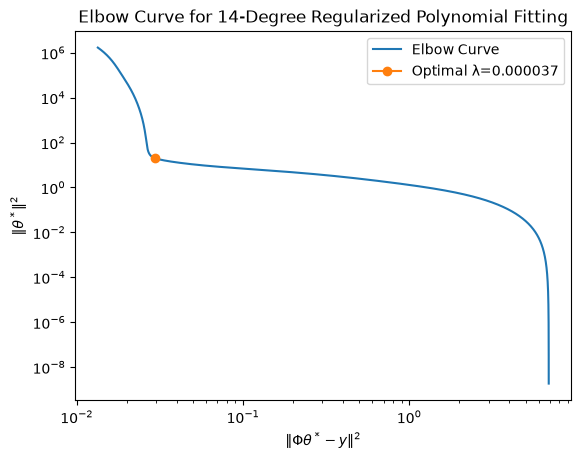

In [24]:
# Question 4: your code here

# Parameters
a, b = 0.3, 6.1
sigma = 0.12
n_samples = 15

# Target Function and Domain Discretization
tgt = jnp.sin
x = jnp.linspace(a,b,n_samples)
key = jax.random.PRNGKey(0)
lambdas = jnp.logspace(-10,4,1401)
x_train = tgt(x)

# Drawing Sample and Finding Optimal θ and Associated Loss
@jax.jit
def draw_y(key, phi, lambda_):
    key, subkey = jax.random.split(key)
    y = x_train + sigma*jax.random.normal(subkey, x_train.shape)

    theta = jnp.linalg.solve((phi.T @ phi) + n_samples*lambda_*jnp.eye(phi.shape[1]), phi.T @ y)
    loss = (jnp.linalg.norm(phi @ theta - y)**2)

    return loss, jnp.linalg.norm(theta)**2

make_vander = lambda x: jnp.vander(2*(x-a)/(b-a) - 1, 15, increasing=True)
phi = make_vander(x)
keys = jax.random.split(key, 200)
loss_path, theta_path = jax.vmap(draw_y, in_axes=(None,None,0))(key, phi, lambdas)

# Curvature Function
t = jnp.log(lambdas)
u = jnp.log(loss_path)
v = jnp.log(theta_path)

u_prime = jnp.gradient(u,t)
v_prime = jnp.gradient(v,t)
u_dprime = jnp.gradient(u_prime,t)
v_dprime = jnp.gradient(v_prime,t)

# Curvature Maximization to Find Optimal λ
kappa = (u_prime*v_dprime - u_dprime*v_prime)/(u_prime**2 + v_prime**2)**1.5
elbow = jnp.argmax(kappa)
lambda_star = lambdas[elbow]

print(f"Optimal λ By Elbow Curvature: {lambda_star:.6f}")

# Viz
plt.figure()
plt.loglog(loss_path, theta_path, label="Elbow Curve")
plt.xlabel(r'$\|\Phi \theta^*-y\|^2$')
plt.ylabel(r'$\|\theta^*\|^2$')
plt.title("Elbow Curve for 14-Degree Regularized Polynomial Fitting")
plt.plot(loss_path[elbow],theta_path[elbow], marker='o', label=f"Optimal λ={lambda_star:.6f}")
plt.legend()
plt.savefig("HW3Problem4.jpg")

---

## Question 5

*Notes, Chapter 6, Exercise 30.*

Reproduce Example 6.8.1. Draw $m$ unbiased estimates of a common true loss 1.0 with noise 0.10, take the minimum, and average over many repetitions for $m = 1, 5, 20, 100$. Confirm the optimism values 0, 0.116, 0.186, 0.251, and compare against $\sigma\sqrt{2\log m}$. Then answer the question that matters: if you select among $m$ models on validation and then report the winner's test loss, is that estimate biased?

In [18]:
# Question 5: your code here

model_draws = [1,5,20,100]
true_loss = 1.0
sigma = 0.10
N_iters = 1000
key = jax.random.PRNGKey(0)

@jax.jit
def min_over_model_sizes(key):
    y = true_loss + sigma*jax.random.normal(key, (N_iters,max(model_draws)))
    running_min = jax.lax.cummin(y, axis=1)
    return running_min[:, jnp.array(model_draws)-1]

mins = min_over_model_sizes(key)
mean_loss = mins.mean(axis=0)
optimism = true_loss - mean_loss
bound = sigma*jnp.sqrt(2*jnp.log(jnp.array(model_draws, dtype=float)))

for m, l, o, bd in zip(model_draws, mean_loss, optimism, bound):
    print(f"m = {m:3d}:   mean loss = {l:.3f}   optimism = {o:.3f}   sigma*sqrt(2*log(m)) = {bd:.3f}")

m =   1:   mean loss = 0.997   optimism = 0.003   sigma*sqrt(2*log(m)) = 0.000
m =   5:   mean loss = 0.884   optimism = 0.116   sigma*sqrt(2*log(m)) = 0.179
m =  20:   mean loss = 0.813   optimism = 0.187   sigma*sqrt(2*log(m)) = 0.245
m = 100:   mean loss = 0.748   optimism = 0.252   sigma*sqrt(2*log(m)) = 0.303


---

## Question 6

*Notes, Chapter 6, Exercise 32.*

Reproduce the table of Example 6.7.1: $d = 40$ channels, $n = 80$ samples, signal on three channels with coefficients $(2.5, -1.8, 1.1)$ and $\sigma = 0.5$. Confirm that $\lambda = 0.2$ retains exactly three channels and that they are the right three. Then make it harder: raise $\sigma$ until lasso starts either dropping a real channel or keeping a spurious one, and report the noise level at which that happens. How does the answer change if $n$ is halved to 40?

In [19]:
# Question 6: your code here
theta_true = jnp.zeros(40).at[:3].set(jnp.array([2.5, -1.8, 1.1]))
signal_mask = jnp.zeros(40, dtype=bool).at[:3].set(True)
LAM = 0.2

def make_data(key, n, sigma):
    key_X, key_noise = jax.random.split(key)
    X = jax.random.normal(key_X, shape=(n, 40))
    y = X @ theta_true + sigma*jax.random.normal(key_noise, shape=(n,))
    return X, y

soft = lambda v, t: jnp.sign(v) * jnp.maximum(jnp.abs(v) - t, 0.0)

@jax.jit
def lasso(X, y, lam, n_iter=20000):
    G = (X.T @ X)/X.shape[0]
    b = (X.T @ y)/X.shape[0]
    eta = 1.0/jnp.linalg.eigvalsh(G).max()
    body = lambda _, th: soft(th - eta*(G @ th - b), eta*lam)
    return jax.lax.fori_loop(0, n_iter, body, jnp.zeros(X.shape[1]))

def support_mask(key, n, sigma):
    X, y = make_data(key, n, sigma)
    return lasso(X, y, LAM) != 0.0

key = jax.random.PRNGKey(0)
X, y = make_data(key, 80, 0.5)
mask = lasso(X, y, LAM) != 0.0
print("n=80, sigma=0.5, lambda=0.2: retained channels", np.nonzero(np.asarray(mask))[0].tolist())
print("coefficients:", np.round(np.asarray(lasso(X, y, LAM)[mask]), 3))
print("exactly the three signal channels:", bool(jnp.all(mask == signal_mask)))

def first_failure(n, sigmas=jnp.arange(0.5, 3.01, 0.05)):
    for sig in sigmas:
        m = support_mask(key, n, sig)
        if not bool(jnp.all(m == signal_mask)):
            return round(float(sig), 2), np.nonzero(np.asarray(m))[0].tolist()
    return None

print("n=80: first sigma where support changes:", first_failure(80))
print("n=40: first sigma where support changes:", first_failure(40))

keys = jax.random.split(jax.random.PRNGKey(1), 20)
for n in [80, 40]:
    rates = {}
    for sig in [0.5, 0.8, 1.0]:
        masks = jax.vmap(lambda k: support_mask(k, n, sig))(keys)
        rates[sig] = round(float(jnp.mean(jnp.all(masks == signal_mask, axis=1))), 2)
    print(f"n={n}: fraction of 20 draws with exact support, by sigma: {rates}")


n=80, sigma=0.5, lambda=0.2: retained channels [0, 1, 2]
coefficients: [ 2.321 -1.559  0.904]
exactly the three signal channels: True
n=80: first sigma where support changes: (0.6, [0, 1, 2, 5])
n=40: first sigma where support changes: (0.55, [0, 1, 2, 23])
n=80: fraction of 20 draws with exact support, by sigma: {0.5: 0.8, 0.8: 0.35, 1.0: 0.05}
n=40: fraction of 20 draws with exact support, by sigma: {0.5: 0.25, 0.8: 0.0, 1.0: 0.0}


---

## Question 7

*Notes, Chapter 7, Exercise 15.*

Implement the coin likelihood of Example 7.5.1 in JAX and reproduce Figure 7.3 for $n = 5, 20, 100$. Measure the width of each curve at half its peak and check that it shrinks like $n^{-1/2}$, as Theorem 5.6.2 would suggest.

n = 5: # Heads = 2 # Tails = 3 θ = 0.400 Width = 0.4828
n = 20: # Heads = 10 # Tails = 10 θ = 0.500 Width = 0.2590
n = 100: # Heads = 63 # Tails = 37 θ = 0.630 Width = 0.1137


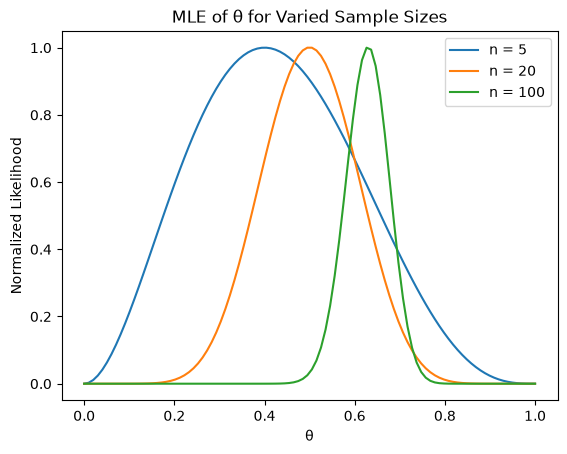

In [20]:
# Question 7: your code here
key = jax.random.PRNGKey(0)

n_samples = [5, 20, 100]

@jax.jit
def flip_coin(key):
    key, subkey = jax.random.split(key)
    flip = jnp.round(jax.random.uniform(subkey))
    return flip

# Plot Likelihood Function for θ in [0,1]
theta_sweep = jnp.linspace(0,1,100)
plt.figure()
num_heads = np.zeros_like(n_samples)
num_tails = np.zeros_like(n_samples)
thetas = np.zeros_like(n_samples,dtype=jnp.float64)
for i in range(len(n_samples)):
    keys = jax.random.split(key, n_samples[i])
    flips = jax.vmap(flip_coin)(keys)
    thetas[i] = jnp.mean(flips)
    num_heads[i] = jnp.sum(flips)
    num_tails[i] = n_samples[i] - num_heads[i]

    L = (theta_sweep)**num_heads[i] * (1.0 - theta_sweep)**num_tails[i]
    L = jnp.asarray(L/L.max())
    peak_idx = int(jnp.argmax(L))
    plt.plot(theta_sweep, L/L.max(), label=f"n = {n_samples[i]}")

    lower_half, upper_half = jnp.where(L[:peak_idx] <= 0.5)[0], jnp.where(L[peak_idx:] <= 0.5)[0]
    lo, hi = lower_half[-1], peak_idx + upper_half[0]
    left = np.interp(0.5, [L[lo], L[lo+1]], [theta_sweep[lo], theta_sweep[lo+1]])
    right = np.interp(0.5, [L[hi], L[hi-1]], [theta_sweep[hi], theta_sweep[hi-1]])

    print(f"n = {n_samples[i]}: # Heads = {num_heads[i]} # Tails = {num_tails[i]} θ = {thetas[i]:.3f} Width = {right-left:.4f}")

plt.legend()
plt.xlabel("θ")
plt.ylabel("Normalized Likelihood")
plt.title("MLE of θ for Varied Sample Sizes")
plt.savefig("HW3Problem7.jpg")

---

## Question 8

*Notes, Chapter 7, Exercise 18.*

Reproduce Figure 7.2 analytically for a mixture of two Gaussians approximated by one. Show that minimizing $D_{\mathrm{KL}}(p \,\|\, q)$ matches the first two moments of $p$, and argue why minimizing $D_{\mathrm{KL}}(q \,\|\, p)$ instead concentrates on a single mode.

---

## Question 9

*Notes, Chapter 7, Exercise 20.*

Reproduce Figure 7.6. Fit a ridge model to nine synthetic points, compute the posterior covariance $\boldsymbol{\Sigma} = \sigma^2(\boldsymbol{\Phi}^\top\boldsymbol{\Phi} + \lambda\mathbf{I})^{-1}$, and plot both bands. Then extrapolate to $x = 20$ and report the ratio of the two widths. At what $x$ does the ratio exceed two?

Ratio of widths at x = 20: 3.681
x value yielding a ratio of 2: 11.083


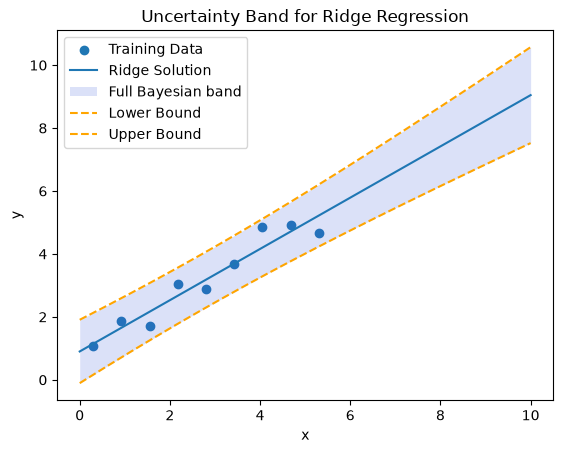

In [21]:
# Question 9: your code here
key = jax.random.PRNGKey(0)

sigma = 0.42
gamma = 2.0
lambda_ = (sigma/gamma)**2

x_train = jnp.linspace(0.3,5.3,9)
y_train = 1.2 + 0.8*x_train + sigma*jax.random.normal(key, x_train.shape)

make_features = lambda x: jnp.stack([jnp.ones_like(x), x], axis=1)
Phi = make_features(x_train)

ridge_mat = Phi.T @ Phi + lambda_*jnp.eye(Phi.shape[1])
theta = jnp.linalg.solve(ridge_mat, Phi.T @ y_train)
cov = sigma**2 * jnp.linalg.inv(ridge_mat)

def compute_variance(x):
    phi = make_features(jnp.atleast_1d(jnp.asarray(x, float)))
    return sigma**2 + jnp.einsum('ij,jk,ik->i', phi, cov, phi)

x_plot = jnp.linspace(0,10,401)
plt.figure()
plt.scatter(x_train, y_train, label="Training Data")
plt.plot(x_plot, theta[0]+theta[1]*x_plot, label="Ridge Solution")

mean_x = make_features(x_plot) @ theta
stdev_x = jnp.sqrt(compute_variance(x_plot))

plt.fill_between(x_plot, mean_x - 2*stdev_x, mean_x + 2*stdev_x, color="#3b5bdb", alpha=0.18, lw=0, label="Full Bayesian band")
plt.plot(x_plot, mean_x - 2*stdev_x, linestyle="--", label="Lower Bound", color="orange")
plt.plot(x_plot, mean_x + 2*stdev_x, linestyle="--", label="Upper Bound", color="orange")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Uncertainty Band for Ridge Regression")
plt.legend()

plt.savefig("HW3Problem9.jpg")

# Extrapolation
x_test = 20.0
ratio = lambda x: jnp.sqrt(compute_variance(x))/sigma

print(f"Ratio of widths at x = 20: {ratio(x_test)[0]:.3f}")
# When does ratio exceed 2?
a = cov[1,1]
b = 2*cov[0,1]
c = cov[0,0] - 3*sigma**2

x_crossover = (-1*b + jnp.sqrt(b**2 - 4*a*c))/(2*a)
print(f"x value yielding a ratio of 2: {x_crossover:.3f}")

---

## Question 10

*Notes, Chapter 8, Exercise 7.*

Compute $\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$ for the cross entropy loss and show it takes the form $\sum_i \big(\sigma(\boldsymbol{\theta} \cdot \mathbf{x}^{(i)}) - y^{(i)}\big)\mathbf{x}^{(i)}$, structurally identical to the $L_2$ gradient of Chapter 3 with the model output replaced by $\sigma(\boldsymbol{\theta} \cdot \mathbf{x})$. What is the practical consequence for implementation?

---

## Question 11

*Notes, Chapter 8, Exercise 12.*

On perfectly separable data the cross entropy minimizer does not exist: show that $J(\boldsymbol{\theta})$ can be driven toward zero by scaling $\boldsymbol{\theta} \to c\,\boldsymbol{\theta}$ with $c \to \infty$, so $\|\boldsymbol{\theta}^\star\|$ diverges. What does Chapter 6 offer as a remedy?

---

## Question 12

*Notes, Chapter 8, Exercise 18.*

Reproduce Figure 8.1. Fit least squares to a one dimensional two class dataset, then move a single correctly labeled point steadily to the right and record the threshold as a function of its position. At what distance does the first misclassification occur? Repeat with logistic regression and plot both curves.

PART 1 — Figure 8.1
  (a) clean data      : threshold = 2.3000, misclassified = 0
  (b) outlier at x=26 : threshold = 2.9270, misclassified = 2

PART 2 — sweeping the moved point from x = 4.4 to 30
  LS threshold drifts      : 2.3469 -> 2.9679
  logistic threshold       : 2.4183 -> 2.4183
  first LS misclassification at x = 9.7161 (moved 5.3161)
  threshold at that point  : 2.6000 (= the leftmost class-1 point)
  logistic ever misclassifies: False


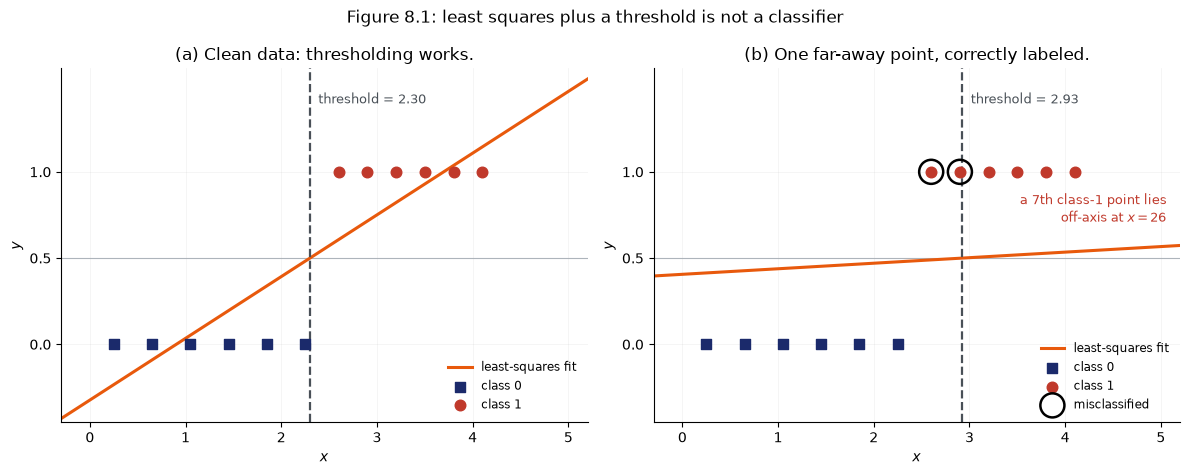

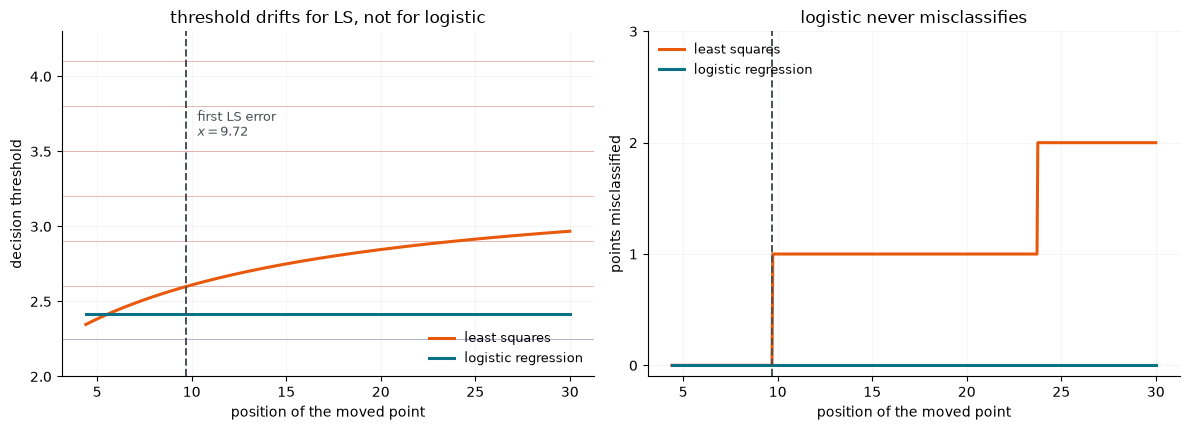

In [22]:
# Question 12: your code here

x_base        = jnp.array([0.25, 0.65, 1.05, 1.45, 1.85, 2.25])   # class 0
x_pos         = jnp.array([2.6, 2.9, 3.2, 3.5, 3.8, 4.1])         # class 1, fixed
x_moved_start = 4.4                                                # the mobile class-1 point

def dataset(x_moved):
    x = jnp.concatenate([x_base, x_pos, jnp.array([x_moved])])
    y = jnp.concatenate([jnp.zeros(x_base.size), jnp.ones(x_pos.size + 1)])
    return x, y

def ls_weights(x, y):
    X = jnp.column_stack([x, jnp.ones_like(x)])
    return jnp.linalg.lstsq(X, y)[0]

@jax.jit
def fit_least_squares(x, y):
    w, b = ls_weights(x, y)
    pred = (w*x + b >= 0.5).astype(y.dtype)
    return (0.5 - b)/w, jnp.sum(pred != y)

@jax.jit
def logistic_weights(x, y, n_iter=20000, lr=0.5):
    X = jnp.column_stack([x, jnp.ones_like(x)])
    body = lambda _, w: w - lr*X.T @ (jax.nn.sigmoid(X @ w) - y)/y.size
    return jax.lax.fori_loop(0, n_iter, body, jnp.zeros(2))

@jax.jit
def fit_logistic(x, y):
    w = logistic_weights(x, y)
    pred = (x*w[0] + w[1] >= 0).astype(y.dtype)
    return -w[1]/w[0], jnp.sum(pred != y)

C_FIT, C_THR, C0, C1, C_LOG = "#e8590c", "#495057", "#1b2a6b", "#c0392b", "#0b7285"

# Figure 8.1 Reproduction
x_clean = jnp.concatenate([x_base, x_pos])
y_clean = jnp.concatenate([jnp.zeros(x_base.size), jnp.ones(x_pos.size)])

t_clean, n_clean = fit_least_squares(x_clean, y_clean)
x26, y26         = dataset(26.0)
t26, n26         = fit_least_squares(x26, y26)

print("PART 1 — Figure 8.1")
print(f"  (a) clean data      : threshold = {float(t_clean):.4f}, misclassified = {int(n_clean)}")
print(f"  (b) outlier at x=26 : threshold = {float(t26):.4f}, misclassified = {int(n26)}")

def draw_panel(ax, x, y, xlim, title):
    x, y = np.asarray(x), np.asarray(y)
    w, b = (float(v) for v in ls_weights(jnp.asarray(x), jnp.asarray(y)))
    t     = (0.5 - b)/w
    wrong = (w*x + b >= 0.5) != (y == 1)
    grid  = np.linspace(*xlim, 400)

    ax.axhline(0.5, color="#adb5bd", lw=0.8, zorder=1)
    ax.plot(grid, w*grid + b, color=C_FIT, lw=2.2, zorder=2, label="least-squares fit")
    ax.axvline(t, color=C_THR, ls="--", lw=1.6, zorder=2)
    ax.annotate(f"threshold = {t:.2f}", (t, 1.42), xytext=(6, 0), textcoords="offset points",
                fontsize=9, color=C_THR, va="center")
    ax.scatter(x[y == 0], y[y == 0], marker="s", s=58, color=C0, zorder=4, label="class 0")
    ax.scatter(x[y == 1], y[y == 1], marker="o", s=58, color=C1, zorder=4, label="class 1")
    if wrong.any():
        ax.scatter(x[wrong], y[wrong], s=300, facecolors="none", edgecolors="k",
                   lw=1.8, zorder=5, label="misclassified")
    ax.set(xlim=xlim, ylim=(-0.45, 1.6), xlabel="$x$", ylabel="$y$", title=title,
           yticks=[0, 0.5, 1])
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    ax.grid(alpha=.18, lw=.5); ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
draw_panel(axes[0], x_clean, y_clean, (-0.3, 5.2), "(a) Clean data: thresholding works.")
draw_panel(axes[1], x26,     y26,     (-0.3, 5.2), "(b) One far-away point, correctly labeled.")
axes[1].text(0.975, 0.652, "a 7th class-1 point lies\noff-axis at $x = 26$",
             transform=axes[1].transAxes, ha="right", va="top",
             fontsize=9, color=C1, linespacing=1.4)
fig.suptitle("Figure 8.1: least squares plus a threshold is not a classifier", fontsize=12)
fig.tight_layout(); plt.savefig("HW3Problem12_fig81.jpg", dpi=150, bbox_inches="tight")


# Sweeping outlier
def both_fits(x_moved):
    x, y = dataset(x_moved)
    t_ls, n_ls = fit_least_squares(x, y)
    t_lr, n_lr = fit_logistic(x, y)
    return t_ls, t_lr, n_ls, n_lr

sweep_x = jnp.linspace(x_moved_start, 30.0, 600)
thr_ls, thr_lr, wrong_ls, wrong_lr = jax.vmap(both_fits)(sweep_x)

lo, hi = x_moved_start, 40.0
for _ in range(60):
    mid = (lo + hi)/2
    if fit_least_squares(*dataset(mid))[1] > 0: hi = mid
    else:                                       lo = mid
x_first = hi

print("\nPART 2 — sweeping the moved point from "
      f"x = {x_moved_start} to {float(sweep_x[-1]):.0f}")
print(f"  LS threshold drifts      : {float(thr_ls[0]):.4f} -> {float(thr_ls[-1]):.4f}")
print(f"  logistic threshold       : {float(thr_lr[0]):.4f} -> {float(thr_lr[-1]):.4f}")
print(f"  first LS misclassification at x = {x_first:.4f} "
      f"(moved {x_first - x_moved_start:.4f})")
print(f"  threshold at that point  : {float(fit_least_squares(*dataset(x_first))[0]):.4f} "
      "(= the leftmost class-1 point)")
print(f"  logistic ever misclassifies: {bool(jnp.any(wrong_lr > 0))}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
sx = np.asarray(sweep_x)
for xb in np.asarray(x_base): ax[0].axhline(xb, color=C0, lw=0.7, alpha=0.35)
for xp in np.asarray(x_pos):  ax[0].axhline(xp, color=C1, lw=0.7, alpha=0.35)
ax[0].plot(sx, np.asarray(thr_ls), lw=2.2, color=C_FIT, label="least squares")
ax[0].plot(sx, np.asarray(thr_lr), lw=2.2, color=C_LOG, label="logistic regression")
ax[0].axvline(x_first, ls="--", lw=1.4, color=C_THR)
ax[0].annotate(f"first LS error\n$x={x_first:.2f}$", (x_first, 3.6), xytext=(8, 0),
               textcoords="offset points", fontsize=9, color=C_THR)
ax[0].set(xlabel="position of the moved point", ylabel="decision threshold", ylim=(2.0, 4.3),
          title="threshold drifts for LS, not for logistic")
ax[0].legend(frameon=False, fontsize=9, loc="lower right")

ax[1].plot(sx, np.asarray(wrong_ls), lw=2.2, color=C_FIT, label="least squares")
ax[1].plot(sx, np.asarray(wrong_lr), lw=2.2, color=C_LOG, label="logistic regression")
ax[1].axvline(x_first, ls="--", lw=1.4, color=C_THR)
ax[1].set(xlabel="position of the moved point", ylabel="points misclassified",
          yticks=[0, 1, 2, 3], title="logistic never misclassifies")
ax[1].legend(frameon=False, fontsize=9, loc="upper left")
for a in ax: a.grid(alpha=.18, lw=.5); a.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.savefig("HW3Problem12.jpg", dpi=150, bbox_inches="tight")
